<a href="https://colab.research.google.com/github/martinabergonzoni/SEGMENTAZIONE-DELLA-CLIENTELA-PER-ATTIVITA-DI-MARKETING/blob/main/Customer_segmentation_for_targeted_marketing_campaigns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries and uploading files

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

import os

sns.set(style="whitegrid", palette="viridis")

df = pd.read_csv("credit_card_customers.csv")
print("Shape:", df.shape)
display(df.head())


Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Data preprocessing

In [ ]:
#general information and insights into missing values
display(df.info())
display(df.describe())
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values (if >0):\n", missing[missing>0])

#remove spaces
df.columns = [c.strip() for c in df.columns]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

None

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


Missing values (if >0):
 MINIMUM_PAYMENTS    313
CREDIT_LIMIT          1
dtype: int64


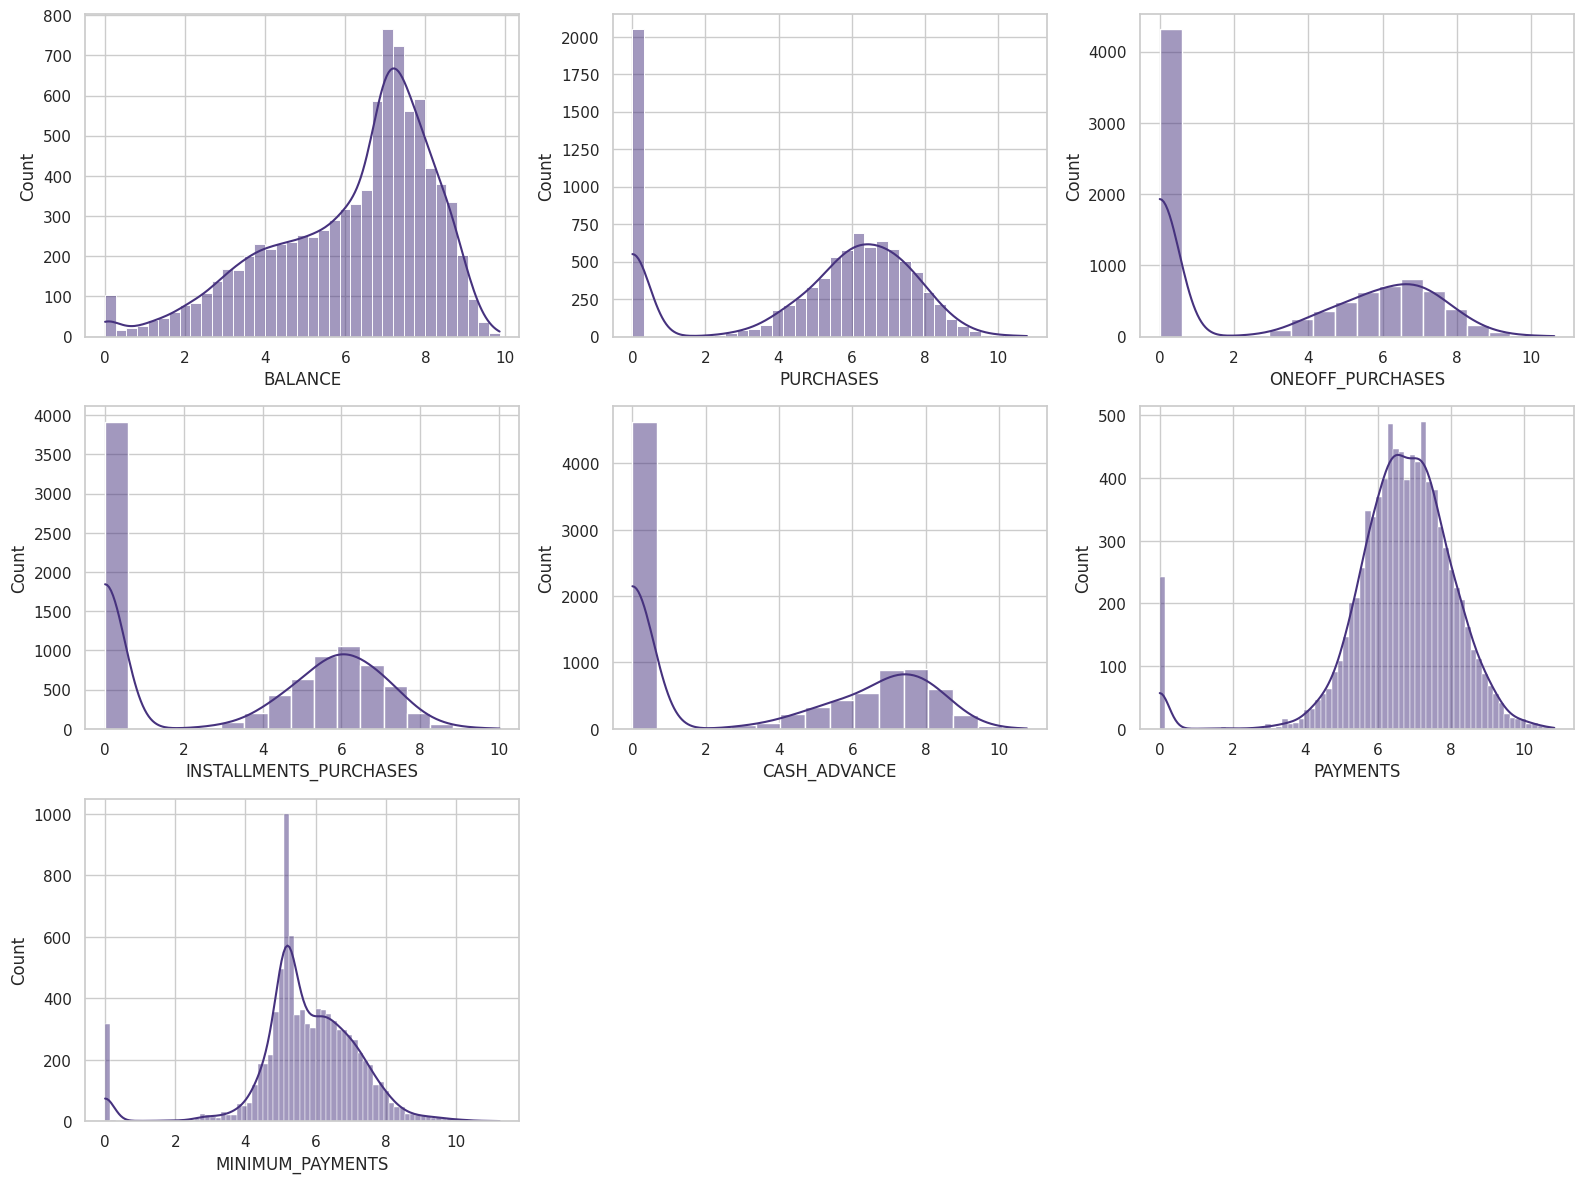

In [ ]:
#visualization of monetary distributions on a logarithmic scale
monetary_candidates = ["BALANCE","PURCHASES","ONEOFF_PURCHASES","INSTALLMENTS_PURCHASES",
                       "CASH_ADVANCE","PAYMENTS","MINIMUM_PAYMENTS"]
monetary = [c for c in monetary_candidates if c in df.columns]

plt.figure(figsize=(16,12))
for i, col in enumerate(monetary, 1):
    plt.subplot(3,3,i)
    sns.histplot(np.log1p(df[col].fillna(0)), kde=True)
plt.tight_layout()
plt.show()

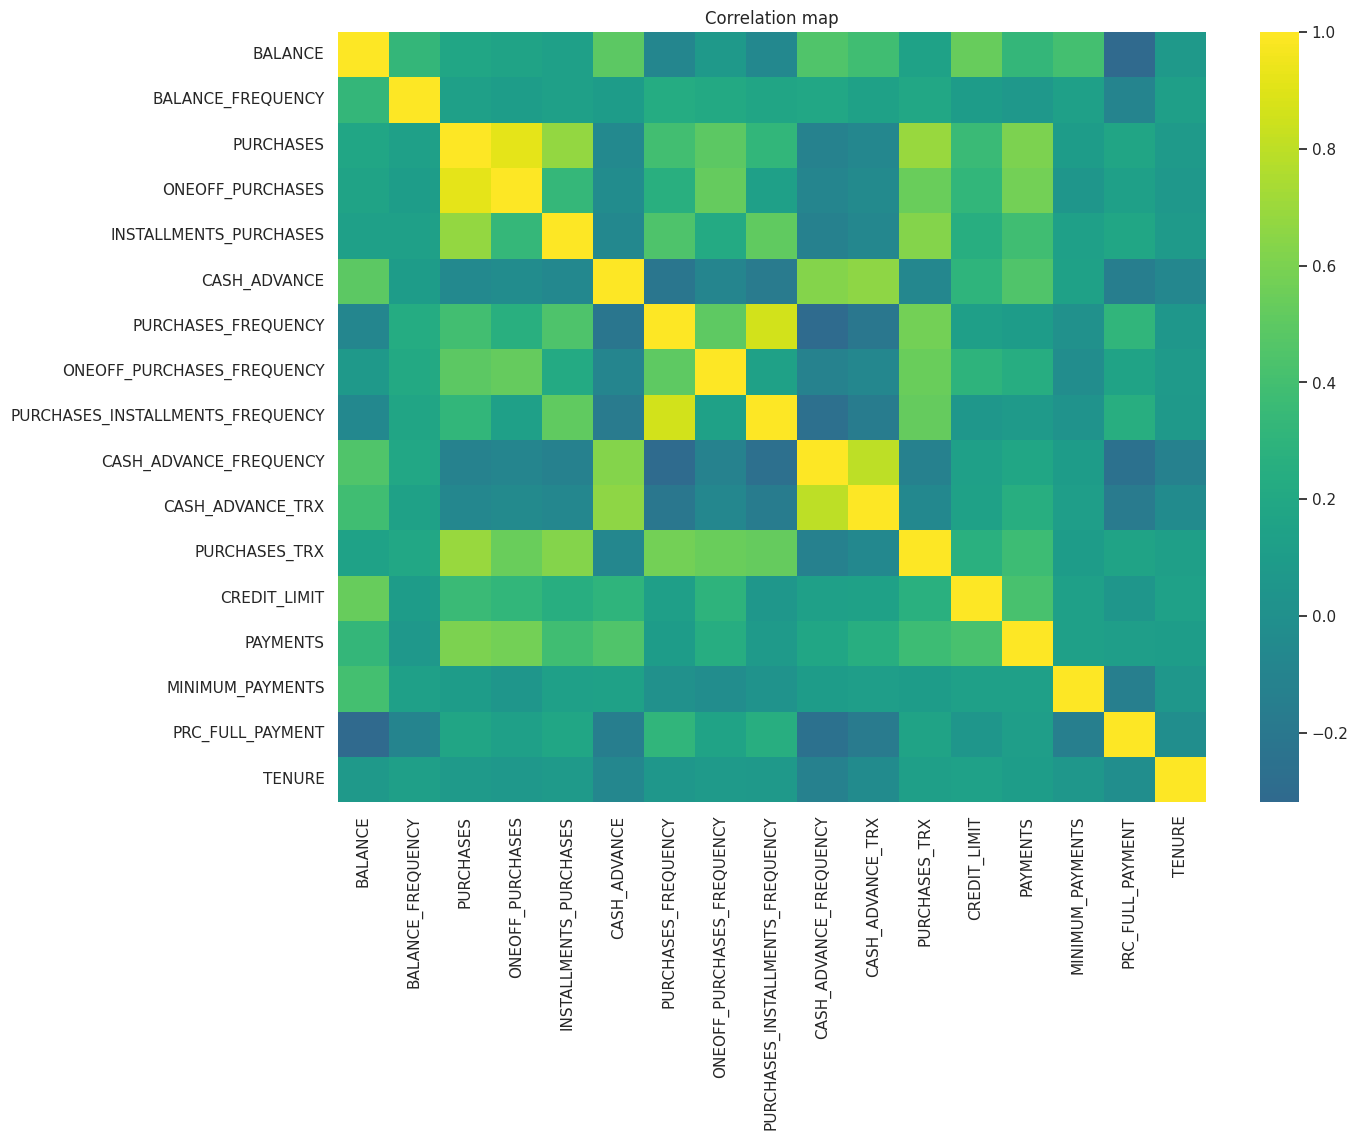

In [ ]:
#correlation between numerical variables
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14,10))
sns.heatmap(num_df.corr(), cmap="viridis", center=0)
plt.title("Correlation map")
plt.show()

Used numeric columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


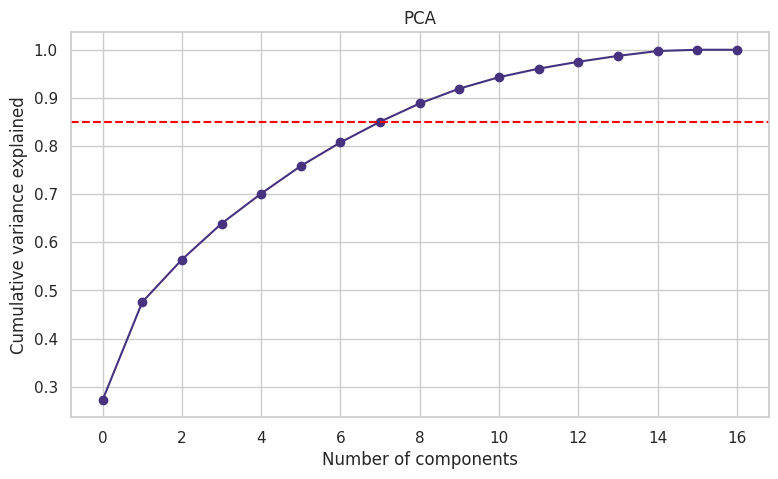

Components to explain at least 85% of the variance: 8


In [ ]:
if "CUST_ID" in df.columns:
    df_proc = df.drop(columns=["CUST_ID"]).copy()
else:
    df_proc = df.copy()

#I select only the numeric columns
num_cols = df_proc.select_dtypes(include=[np.number]).columns.tolist()
print("Used numeric columns:", num_cols)

#assignment of the median value
df_proc[num_cols] = df_proc[num_cols].fillna(df_proc[num_cols].median())

#standardization
scaler = StandardScaler()
scaled = scaler.fit_transform(df_proc[num_cols])
scaled_df = pd.DataFrame(scaled, columns=num_cols, index=df_proc.index)

#PCA
pca_full = PCA()
pca_full.fit(scaled_df)
explained_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9,5))
plt.plot(explained_var, marker='o')
plt.axhline(0.85, color='red', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained")
plt.title("PCA")
plt.grid(True)
plt.show()

n_components = np.argmax(explained_var >= 0.85) + 1
print("Components to explain at least 85% of the variance:", n_components)

pca = PCA(n_components=n_components, random_state=42)
pca_data = pca.fit_transform(scaled_df)


Segmentation via Clustering

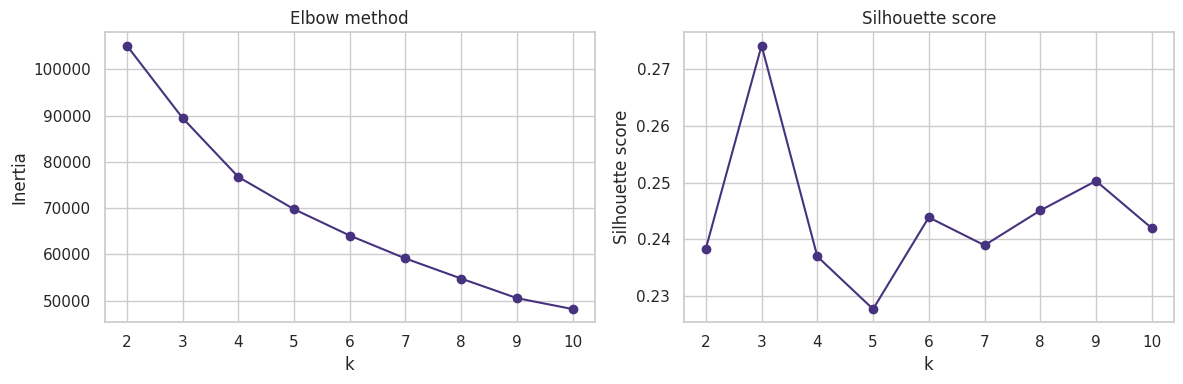

In [ ]:
#Elbow and silhouette to choose k
inertia = []
sil_scores = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_data)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(pca_data, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")

plt.subplot(1,2,2)
plt.plot(K, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score")
plt.tight_layout()
plt.show()

In [ ]:
for k, s in zip(K, sil_scores):
    print(f"k={k} -> silhouette={s:.4f}")

k=2 -> silhouette=0.2384
k=3 -> silhouette=0.2741
k=4 -> silhouette=0.2370
k=5 -> silhouette=0.2277
k=6 -> silhouette=0.2439
k=7 -> silhouette=0.2390
k=8 -> silhouette=0.2451
k=9 -> silhouette=0.2503
k=10 -> silhouette=0.2420


In [ ]:
#Choose k
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=50)
clusters = kmeans.fit_predict(pca_data)
df["CLUSTER"] = clusters
print("Cluster distribution:\n", df["CLUSTER"].value_counts())

Cluster distribution:
 CLUSTER
3    4034
2    3343
0    1229
1     344
Name: count, dtype: int64


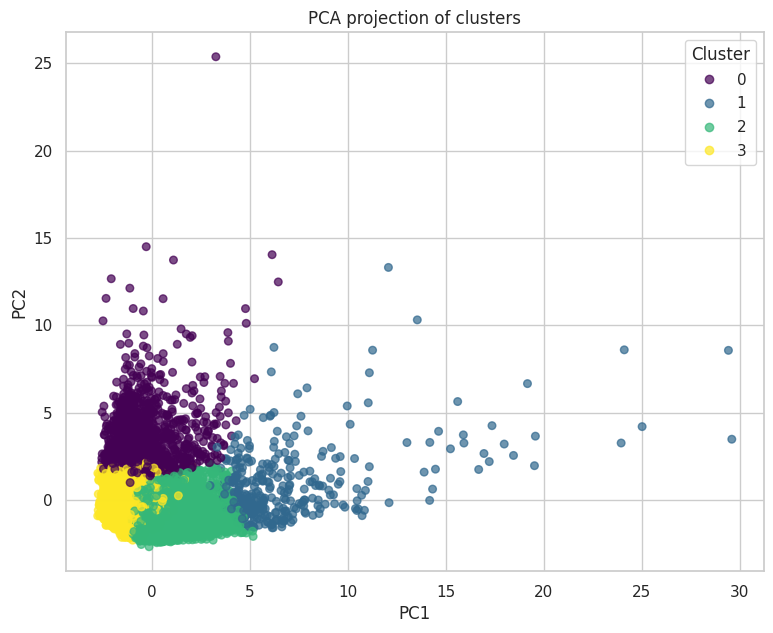

In [ ]:
# PCA Visualization
plt.figure(figsize=(9,7))
scatter = plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap="viridis", s=30, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of clusters")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

In [ ]:
#Stability
def clustering_stability(data_pca, k, runs=30):
    labels_list = []
    silhouettes = []
    for i in range(runs):
        km = KMeans(n_clusters=k, random_state=42+i, n_init=10)
        lab = km.fit_predict(data_pca)
        labels_list.append(lab)
        silhouettes.append(silhouette_score(data_pca, lab))
    return {
        "silhouette_mean": np.mean(silhouettes),
        "silhouette_std": np.std(silhouettes),
    }

for k in [max(2, k_opt-1), k_opt, k_opt+1]:
    stats = clustering_stability(pca_data, k, runs=20)
    print(f"K = {k} → silhouette mean {stats['silhouette_mean']:.4f} ± {stats['silhouette_std']:.4f}")

K = 3 → silhouette mean 0.2727 ± 0.0075
K = 4 → silhouette mean 0.2364 ± 0.0005
K = 5 → silhouette mean 0.2281 ± 0.0005


In [ ]:
#Profiling
profile = df_proc.copy()
profile["CLUSTER"] = df["CLUSTER"]
cluster_profile = profile.groupby("CLUSTER").mean()
display(cluster_profile)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CLUSTER,,,,,,,,,,,,,,,,,
0,4552.851781,0.968679,488.664516,311.734882,177.012360,4466.275421,0.281577,0.135978,0.180787,0.479390,14.077299,7.470301,7477.831201,3436.212623,2005.534180,0.035356,11.391375
1,3797.511375,0.986469,8384.853459,5631.435291,2755.162355,769.495822,0.945014,0.745195,0.781444,0.078946,2.418605,92.316860,10009.011628,8063.256148,2169.760665,0.280794,11.959302
2,927.741118,0.940615,1308.244852,635.139512,673.292145,212.099062,0.892982,0.309078,0.720456,0.042755,0.795692,23.435238,4310.191520,1381.612293,650.493310,0.274978,11.615316
3,991.277243,0.787617,277.705117,212.867419,65.174948,569.680277,0.181521,0.088073,0.089793,0.111622,2.053545,3.066683,3267.601223,965.801227,539.444038,0.078445,11.436787


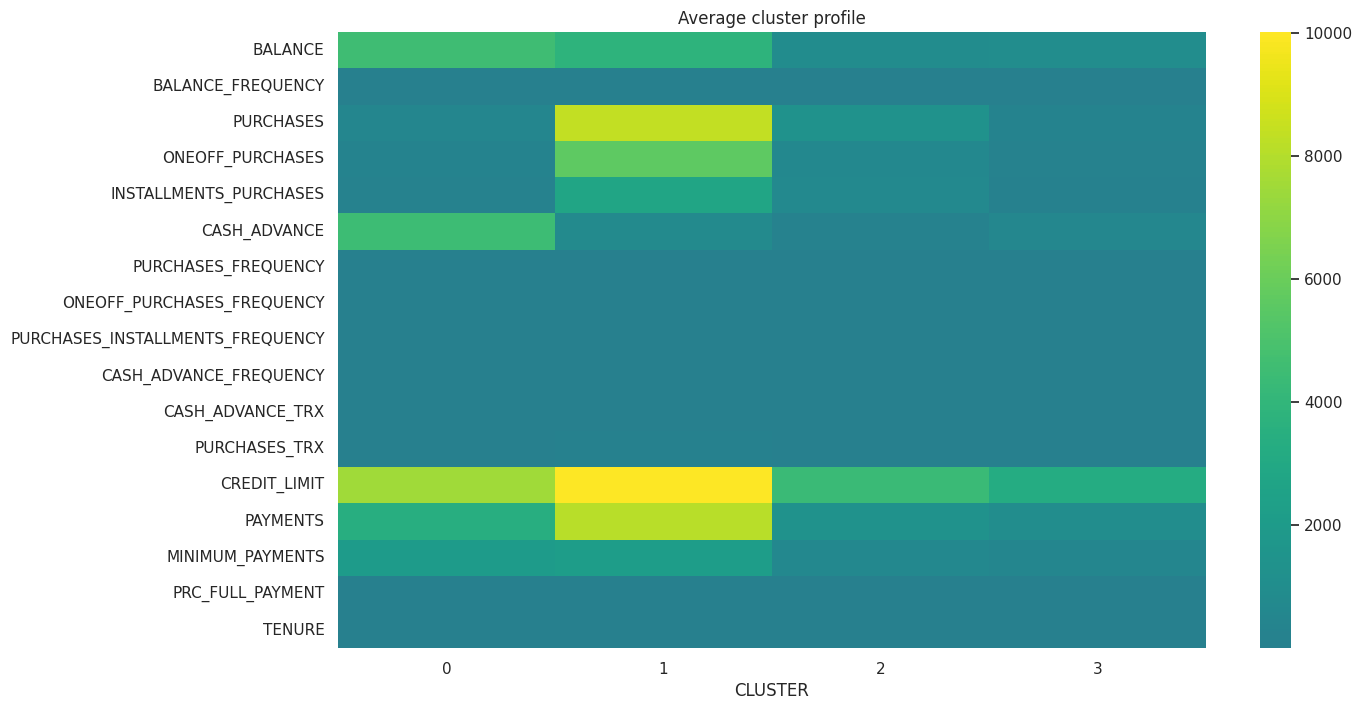

In [ ]:
#Heatmap profiles
plt.figure(figsize=(14,8))
sns.heatmap(cluster_profile.T, cmap="viridis", center=cluster_profile.values.mean())
plt.title("Average cluster profile")
plt.show()

In [ ]:
#I define groups of variables
spese_cols = [c for c in ["BALANCE","PURCHASES","ONEOFF_PURCHASES","INSTALLMENTS_PURCHASES"] if c in cluster_profile.columns]
pagamenti_cols = [c for c in ["MINIMUM_PAYMENTS","PRCFULLPAYMENT","PAYMENTS"] if c in cluster_profile.columns]
frequenza_cols = [c for c in ["CASH_ADVANCE","CASHADVANCETRX","PURCHASES_FREQUENCY",
                               "ONEOFFPURCHASESFREQUENCY","PURCHASESINSTALLMENTSFREQUENCY","CASHADVANCEFREQUENCY"] if c in cluster_profile.columns]

print("Expences:", spese_cols)
print("Payments:", pagamenti_cols)
print("Frequencies:", frequenza_cols)

cluster_spese = cluster_profile[spese_cols] if spese_cols else pd.DataFrame()
cluster_pagamenti = cluster_profile[pagamenti_cols] if pagamenti_cols else pd.DataFrame()
cluster_frequenze = cluster_profile[frequenza_cols] if frequenza_cols else pd.DataFrame()

display(cluster_spese)
display(cluster_pagamenti)
display(cluster_frequenze)

Expences: ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES']
Payments: ['MINIMUM_PAYMENTS', 'PAYMENTS']
Frequencies: ['CASH_ADVANCE', 'PURCHASES_FREQUENCY']


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES
CLUSTER,,,,
0,4552.851781,488.664516,311.734882,177.012360
1,3797.511375,8384.853459,5631.435291,2755.162355
2,927.741118,1308.244852,635.139512,673.292145
3,991.277243,277.705117,212.867419,65.174948


,MINIMUM_PAYMENTS,PAYMENTS
CLUSTER,,
0,2005.534180,3436.212623
1,2169.760665,8063.256148
2,650.493310,1381.612293
3,539.444038,965.801227


,CASH_ADVANCE,PURCHASES_FREQUENCY
CLUSTER,,
0,4466.275421,0.281577
1,769.495822,0.945014
2,212.099062,0.892982
3,569.680277,0.181521


In [ ]:
#Cluster description
for c in sorted(cluster_profile.index):
    print(f"\n==================== CLUSTER {c} ====================")
    if not cluster_spese.empty:
        print("\nAverage expenses:")
        for col in cluster_spese.columns:
            print(f"- {col}: {cluster_spese.loc[c,col]:.2f}")
    if not cluster_pagamenti.empty:
        print("\nPayment habits:")
        for col in cluster_pagamenti.columns:
            print(f"- {col}: {cluster_pagamenti.loc[c,col]:.2f}")
    if not cluster_frequenze.empty:
        print("\nFrequency of use:")
        for col in cluster_frequenze.columns:
            print(f"- {col}: {cluster_frequenze.loc[c,col]:.2f}")


==================== CLUSTER 0 ====================

Average expenses:
- BALANCE: 4552.85
- PURCHASES: 488.66
- ONEOFF_PURCHASES: 311.73
- INSTALLMENTS_PURCHASES: 177.01

Payment habits:
- MINIMUM_PAYMENTS: 2005.53
- PAYMENTS: 3436.21

Frequency of use:
- CASH_ADVANCE: 4466.28
- PURCHASES_FREQUENCY: 0.28

==================== CLUSTER 1 ====================

Average expenses:
- BALANCE: 3797.51
- PURCHASES: 8384.85
- ONEOFF_PURCHASES: 5631.44
- INSTALLMENTS_PURCHASES: 2755.16

Payment habits:
- MINIMUM_PAYMENTS: 2169.76
- PAYMENTS: 8063.26

Frequency of use:
- CASH_ADVANCE: 769.50
- PURCHASES_FREQUENCY: 0.95

==================== CLUSTER 2 ====================

Average expenses:
- BALANCE: 927.74
- PURCHASES: 1308.24
- ONEOFF_PURCHASES: 635.14
- INSTALLMENTS_PURCHASES: 673.29

Payment habits:
- MINIMUM_PAYMENTS: 650.49
- PAYMENTS: 1381.61

Frequency of use:
- CASH_ADVANCE: 212.10
- PURCHASES_FREQUENCY: 0.89

==================== CLUSTER 3 ====================

Average expenses:
- BALAN

Interpretation of Clusters

In [ ]:
#Interpretation
print("\nQualitative interpretation:")
for c in sorted(cluster_profile.index):
    print(f"\n==================== CLUSTER {c} ====================")
    if "ONEOFF_PURCHASES" in cluster_spese.columns and "INSTALLMENTS_PURCHASES" in cluster_spese.columns:
        if cluster_spese.loc[c,"ONEOFF_PURCHASES"] > cluster_spese.loc[c,"INSTALLMENTS_PURCHASES"]:
            print("- Preference for large-value single purchases")
        else:
            print("- Trend in hire purchases")
    if "PRC_FULL_PAYMENT" in cluster_profile.columns:
        if cluster_profile.loc[c,"PRC_FULL_PAYMENT"] > 0.5:
            print("- They pay their entire balance often: reliable profile")
        else:
            print("- They rarely pay their entire balance: beware of credit risk")
    if "CASH_ADVANCE" in cluster_frequenze.columns and cluster_frequenze.loc[c,"CASH_ADVANCE"] > df_proc["CASH_ADVANCE"].mean():
        print("- Frequent use of cash advance: possible need for liquidity")
    if "PURCHASES_FREQUENCY" in cluster_frequenze.columns and cluster_frequenze.loc[c,"PURCHASES_FREQUENCY"] < 0.3:
        print("- Low activity: target for reactivation campaigns")
    else:
        print("- Regular activity with use of paper")



Qualitative interpretation:

==================== CLUSTER 0 ====================
- Preference for large-value single purchases
- They rarely pay their entire balance: beware of credit risk
- Frequent use of cash advance: possible need for liquidity
- Low activity: target for reactivation campaigns

==================== CLUSTER 1 ====================
- Preference for large-value single purchases
- They rarely pay their entire balance: beware of credit risk
- Regular activity with use of paper

==================== CLUSTER 2 ====================
- Trend in hire purchases
- They rarely pay their entire balance: beware of credit risk
- Regular activity with use of paper

==================== CLUSTER 3 ====================
- Preference for large-value single purchases
- They rarely pay their entire balance: beware of credit risk
- Low activity: target for reactivation campaigns


In [ ]:
#Calculate KPIs
kpi_funcs = {
    "n_clients": lambda g: g.size,
    "avg_balance": lambda g: g["BALANCE"].mean() if "BALANCE" in g else np.nan,
    "avg_purchases": lambda g: g["PURCHASES"].mean() if "PURCHASES" in g else np.nan,
    "avg_oneoff": lambda g: g["ONEOFF_PURCHASES"].mean() if "ONEOFF_PURCHASES" in g else np.nan,
    "avg_installments": lambda g: g["INSTALLMENTS_PURCHASES"].mean() if "INSTALLMENTS_PURCHASES" in g else np.nan,
    "avg_cash_advance": lambda g: g["CASH_ADVANCE"].mean() if "CASH_ADVANCE" in g else np.nan,
    "avg_prc_full_payment": lambda g: g["PRCFULLPAYMENT"].mean() if "PRCFULLPAYMENT" in g else np.nan,
    "avg_minimum_payments": lambda g: g["MINIMUM_PAYMENTS"].mean() if "MINIMUM_PAYMENTS" in g else np.nan,
    "avg_credit_limit": lambda g: g["CREDIT_LIMIT"].mean() if "CREDIT_LIMIT" in g else np.nan
}

cluster_kpis = profile.groupby("CLUSTER").apply(lambda g: pd.Series({k: func(g) for k, func in kpi_funcs.items()}))
cluster_kpis["arpu_proxy"] = cluster_kpis["avg_purchases"]
cluster_kpis = cluster_kpis.reset_index().set_index("CLUSTER")

#Priority
def assign_priority(row):
    if row["arpu_proxy"] >= cluster_kpis["arpu_proxy"].quantile(0.66) and row["avg_prc_full_payment"] >= 0.5:
        return "High"
    if row["avg_cash_advance"] >= cluster_kpis["avg_cash_advance"].quantile(0.66) and row["avg_prc_full_payment"] < 0.5:
        return "Alta (rischio)"
    if row["arpu_proxy"] >= cluster_kpis["arpu_proxy"].quantile(0.33):
        return "Medium"
    return "Low"

cluster_kpis["priority"] = cluster_kpis.apply(assign_priority, axis=1)
display(cluster_kpis)
cluster_kpis.to_csv("cluster_kpis_summary.csv")
print("KPI saved in cluster_kpis_summary.csv")


def cluster_summary_text(cluster_id, kpis_row):
    lines = []
    lines.append(f"Cluster {cluster_id} — clients: {int(kpis_row['n_clients'])}")
    lines.append(f"Average balance {kpis_row['avg_balance']:.2f}")
    if kpis_row['avg_prc_full_payment'] >= 0.5:
        lines.append("Tendency to weld in full: reliable profile")
    else:
        lines.append("Low full payment percentage: pay attention to credit risk")
    if kpis_row['avg_cash_advance'] > 0:
        lines.append(f"Average cash advance use: {kpis_row['avg_cash_advance']:.2f}")
    actions = []
    if kpis_row['priority'].startswith("High"):
        actions.append("High priority: premium campaigns or risk management")
    if kpis_row['avg_installments'] and kpis_row['avg_installments'] > kpis_row['avg_oneoff']:
        actions.append("Promote installment offers and subsidized plans")
    if kpis_row['arpu_proxy'] < cluster_kpis['arpu_proxy'].median():
        actions.append("Reactivation campaigns with incentives")
    if not actions:
        actions.append("Standard cross-sell and retention campaigns")
    lines.append("Recommended actions: " + "; ".join(actions))
    return "\n".join(lines)

for cid, row in cluster_kpis.iterrows():
    print("\n" + "="*60)
    print(cluster_summary_text(cid, row))
    print("="*60 + "\n")


/tmp/ipython-input-272/2238063753.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_kpis = profile.groupby("CLUSTER").apply(lambda g: pd.Series({k: func(g) for k, func in kpi_funcs.items()}))


,n_clients,avg_balance,avg_purchases,avg_oneoff,avg_installments,avg_cash_advance,avg_prc_full_payment,avg_minimum_payments,avg_credit_limit,arpu_proxy,priority
CLUSTER,,,,,,,,,,,
0,22122.0,4552.851781,488.664516,311.734882,177.012360,4466.275421,NaN,2005.534180,7477.831201,488.664516,Medium
1,6192.0,3797.511375,8384.853459,5631.435291,2755.162355,769.495822,NaN,2169.760665,10009.011628,8384.853459,Medium
2,60174.0,927.741118,1308.244852,635.139512,673.292145,212.099062,NaN,650.493310,4310.191520,1308.244852,Medium
3,72612.0,991.277243,277.705117,212.867419,65.174948,569.680277,NaN,539.444038,3267.601223,277.705117,Low


KPI saved in cluster_kpis_summary.csv

Cluster 0 — clients: 22122
Average balance 4552.85
Low full payment percentage: pay attention to credit risk
Average cash advance use: 4466.28
Recommended actions: Reactivation campaigns with incentives


Cluster 1 — clients: 6192
Average balance 3797.51
Low full payment percentage: pay attention to credit risk
Average cash advance use: 769.50
Recommended actions: Standard cross-sell and retention campaigns


Cluster 2 — clients: 60174
Average balance 927.74
Low full payment percentage: pay attention to credit risk
Average cash advance use: 212.10
Recommended actions: Promote installment offers and subsidized plans


Cluster 3 — clients: 72612
Average balance 991.28
Low full payment percentage: pay attention to credit risk
Average cash advance use: 569.68
Recommended actions: Reactivation campaigns with incentives



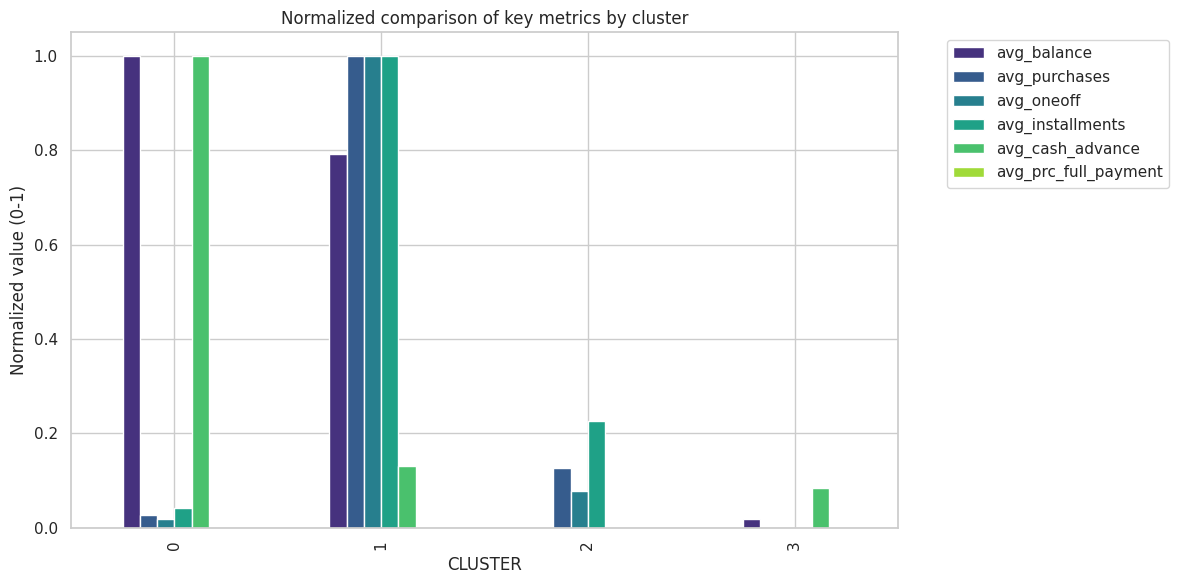

In [ ]:
#Normalized graph
viz_cols = [c for c in ["avg_balance","avg_purchases","avg_oneoff","avg_installments","avg_cash_advance","avg_prc_full_payment"] if c in cluster_kpis.columns]
norm = (cluster_kpis[viz_cols] - cluster_kpis[viz_cols].min()) / (cluster_kpis[viz_cols].max() - cluster_kpis[viz_cols].min())
norm.plot(kind="bar", figsize=(12,6))
plt.title("Normalized comparison of key metrics by cluster")
plt.ylabel("Normalized value (0-1)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.savefig("clusters_barplot_normalized.png", dpi=150)
plt.show()

In [ ]:
# Distintive features for cluster
centroids = kmeans.cluster_centers_
centroids_scaled_approx = pca.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_scaled_approx, columns=scaled_df.columns)
global_mean = scaled_df.mean()
for i in centroids_df.index:
    diff = (centroids_df.loc[i] - global_mean).abs().sort_values(ascending=False)
    top_feats = diff.head(8).index.tolist()
    print(f"\nCluster {i} - top features:", top_feats)


Cluster 0 - top features: ['CASH_ADVANCE', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'BALANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY', 'MINIMUM_PAYMENTS']

Cluster 1 - top features: ['PURCHASES', 'ONEOFF_PURCHASES', 'PURCHASES_TRX', 'INSTALLMENTS_PURCHASES', 'PAYMENTS', 'ONEOFF_PURCHASES_FREQUENCY', 'CREDIT_LIMIT', 'PURCHASES_FREQUENCY']

Cluster 2 - top features: ['PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'PRC_FULL_PAYMENT', 'PURCHASES_TRX', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE', 'INSTALLMENTS_PURCHASES', 'ONEOFF_PURCHASES_FREQUENCY']

Cluster 3 - top features: ['PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'PURCHASES_TRX', 'INSTALLMENTS_PURCHASES', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'CREDIT_LIMIT', 'PURCHASES']


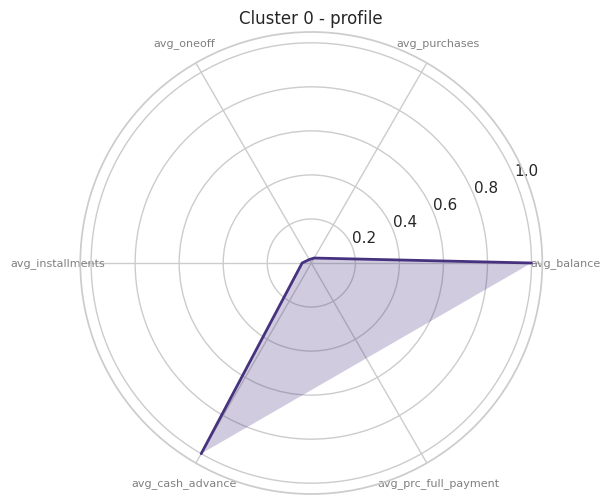

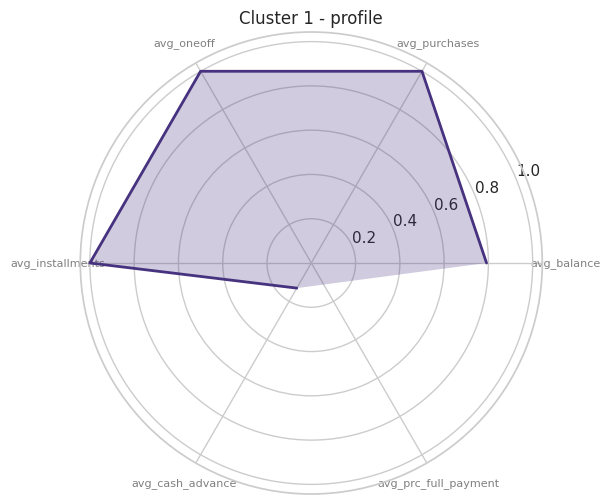

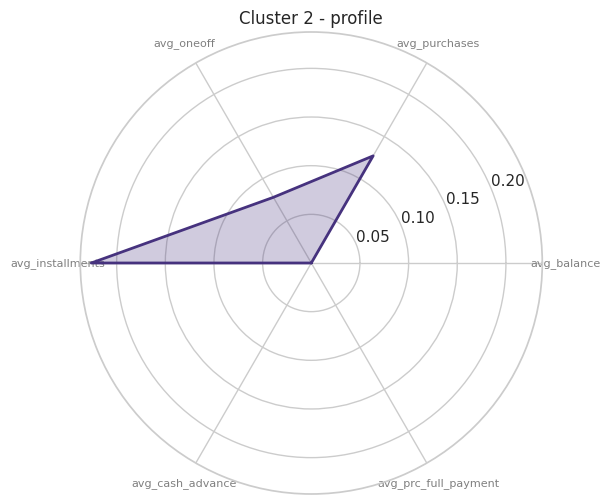

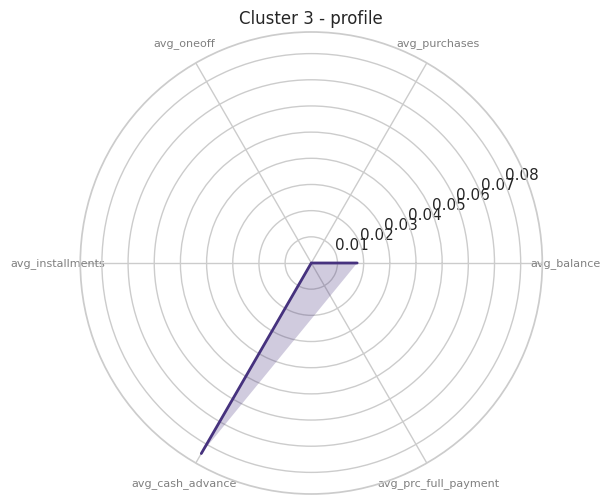

In [ ]:
#Radar chart for each cluster
def radar_plot(row, cols, title, filename):
    N = len(cols)
    values = row[cols].values.flatten().tolist()
    values += values[:1]
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], cols, color='grey', size=8)
    ax.plot(angles, values, linewidth=2, linestyle='solid')
    ax.fill(angles, values, alpha=0.25)
    plt.title(title)
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

for cid in cluster_kpis.index:
    radar_plot(norm.loc[cid], viz_cols, f"Cluster {cid} - profile", f"radar_cluster_{cid}.png")

In [ ]:
#Campaign impact simulation
conversion_rate = 0.02
avg_revenue_per_conversion = 50.0
cost_per_contact = 0.5
sim_results = []
for cid, row in cluster_kpis.iterrows():
    n = int(row["n_clients"])
    expected_conversions = n * conversion_rate
    revenue = expected_conversions * avg_revenue_per_conversion
    cost = n * cost_per_contact
    roi = (revenue - cost) / cost if cost>0 else np.nan
    sim_results.append({
        "cluster": cid,
        "n_clients": n,
        "expected_conversions": expected_conversions,
        "expected_revenue": revenue,
        "campaign_cost": cost,
        "estimated_roi": roi
    })
sim_df = pd.DataFrame(sim_results).set_index("cluster")
display(sim_df)
sim_df.to_csv("campaign_simulation_by_cluster.csv")
print("Simulation saved: campaign_simulation_by_cluster.csv")

,n_clients,expected_conversions,expected_revenue,campaign_cost,estimated_roi
cluster,,,,,
0,22122,442.44,22122.0,11061.0,1.0
1,6192,123.84,6192.0,3096.0,1.0
2,60174,1203.48,60174.0,30087.0,1.0
3,72612,1452.24,72612.0,36306.0,1.0


Simulation saved: campaign_simulation_by_cluster.csv


In [ ]:
#Saving
df.to_csv("credit_card_customers_with_clusters.csv", index=False)
cluster_kpis.to_csv("cluster_kpis_summary.csv")
print("Exported: credit_card_customers_with_clusters.csv, cluster_kpis_summary.csv")
print("Saved graph: clusters_barplot_normalized.png, radar_cluster_*.png")

Exported: credit_card_customers_with_clusters.csv, cluster_kpis_summary.csv
Saved graph: clusters_barplot_normalized.png, radar_cluster_*.png
